
Simple tutorial based on a more complete one: https://github.com/desihub/tutorials/blob/main/01_getting_started/06_PublicDatabaseAccess.ipynb$0

This is not necesarly the best way to access a large volume of data, but should be simple enough for the PCA ejercise.

Make sure to work in a clean enviromen and have Spacl and astrodatalab installed

pip install astro-datalab

pip install sparclclient

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.convolution import convolve, Gaussian1DKernel

## DataLab and SPARCL related modules
from sparcl.client import SparclClient
from dl import queryClient as qc

In [2]:
## Instantiate SPARCLClient
client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [62]:
# Write a query to select the primary spectrum in the Main survey for .1% of the sample
# (see detailed information below)
query = """
        SELECT zp.targetid, zp.z
        FROM desi_dr1.zpix AS zp
        WHERE (zp.survey='main') AND (zp.spectype ='QSO') AND zp.main_primary AND (zp.random_id BETWEEN 0. AND 0.1)
        """ 

## Information about the query
## 
## Selected columns --
##   targetid, survey, program -- unique identifiers for a given spectrum
##   z -- spectroscopic redshift of the target
##   zwarn -- encoded information regarding the redshift (zwarn = 0 is good)
##   spectype -- Spectral type of the target: STAR | GALAXY | QSO
## Constraints (WHERE statement) --
##   survey: selecting main survey only
##   main_primary: keeping only the best spectrum in Main (removes possible multiples)
##   random_id: selects a slice of 1% of the sample (0-1 out of 100)

In [63]:
zpix_cat = qc.query(sql = query, fmt = 'table')
zpix_cat 

targetid,z
int64,float64
39627751036029644,2.240708255153232
39628033765676308,2.361188543850257
39627980468654898,2.516868132018854
39627845382705283,2.578377403839813
39627805423570435,1.195947426767599
39628522691496063,2.038919499292838
39633048932715775,2.071228211281864
39632966330089683,0.9313820300047977
39628473320343415,1.038030129930751


In [64]:
targetid=zpix_cat['targetid'].data.tolist()
# Number of spectra 
n =len(targetid)
n

1721

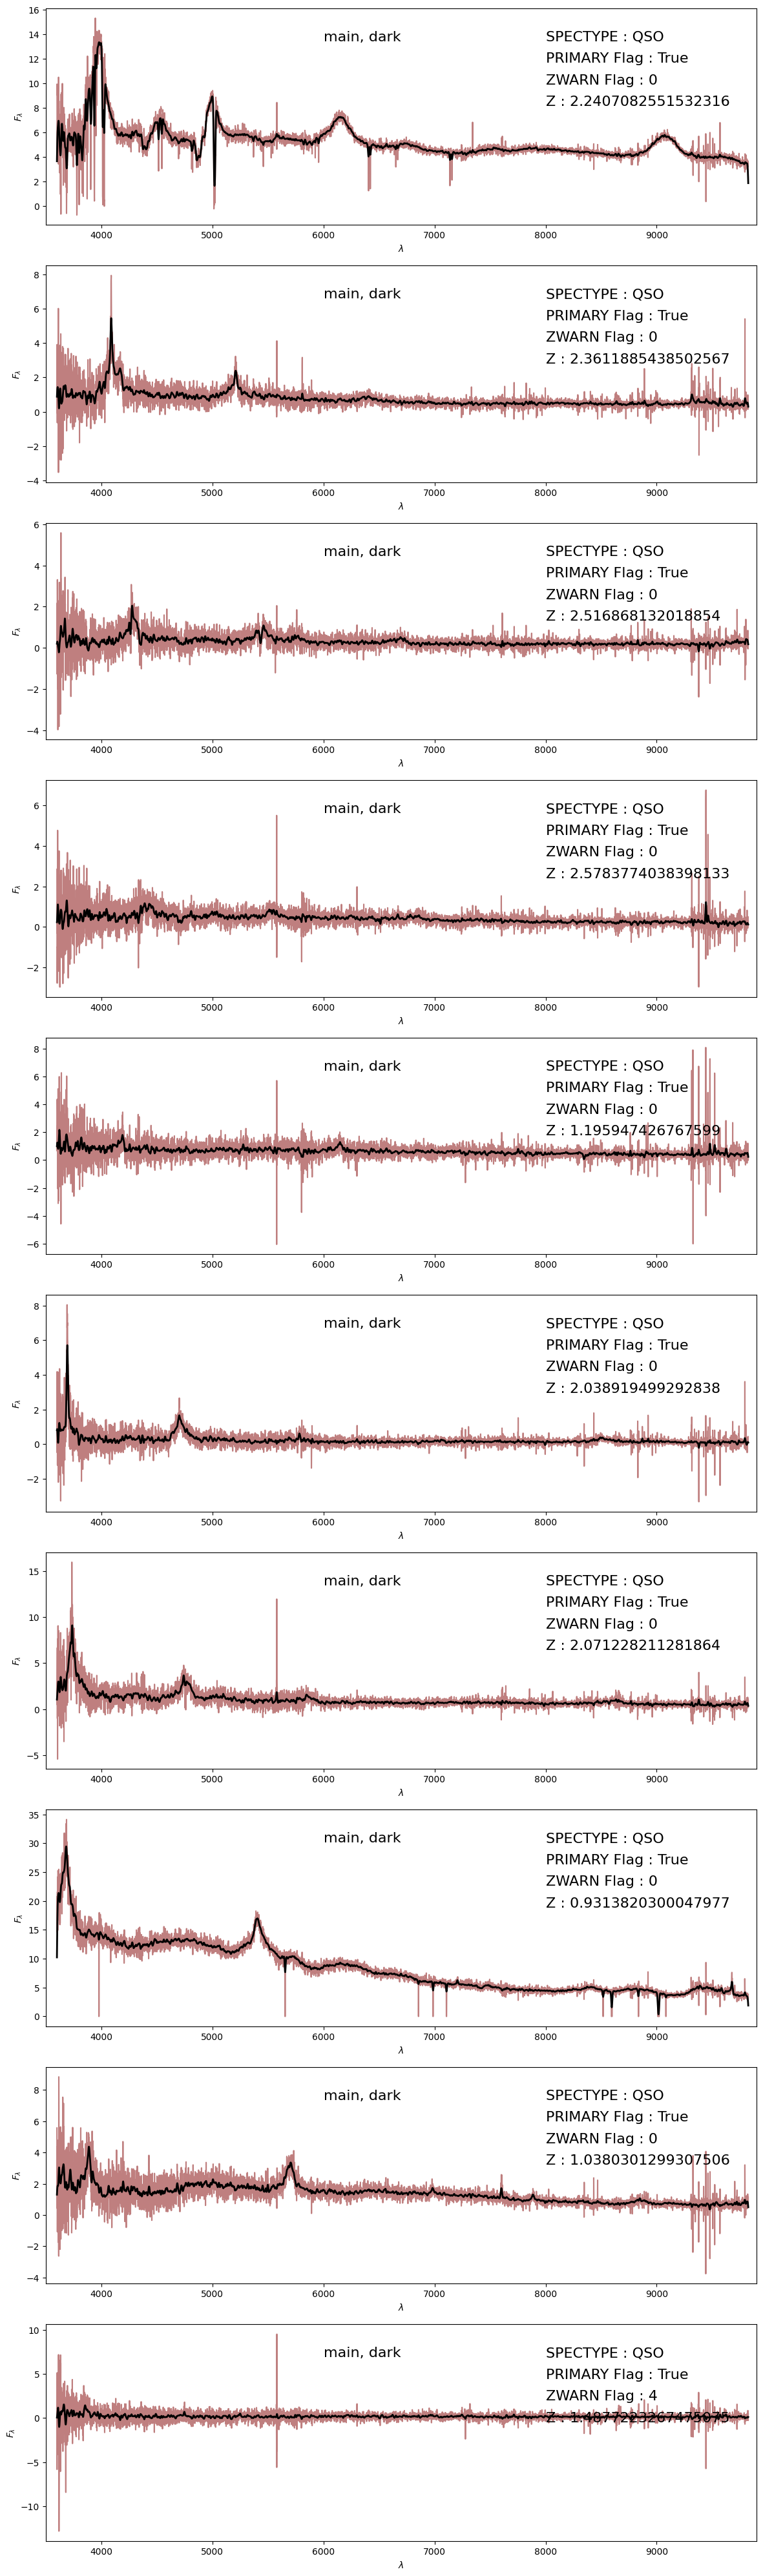

In [66]:
# Number of spectra to plot
n =10 #len(targetid)

fig, ax = plt.subplots(n, 1, figsize = (12,(4*n)))

for jj in range(n):
    inc = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary', 'survey', 'program', 'targetid', 'redshift_warning']
    res = client.retrieve_by_specid(specid_list = [targetid[jj]],
                                include = inc,
                                dataset_list = ['DESI-DR1'])
    records = res.records
    survey = records[0].survey
    program = records[0].program
    spectype = records[0].spectype
    primary_flag = records[0].specprimary
    zwarn_flag = records[0].redshift_warning
    redshift = records[0].redshift

    lam = records[0].wavelength
    flam = records[0].flux
    
    # Plot the combined spectrum in maroon
    ax[jj].plot(lam, flam, color = 'maroon', alpha = 0.5)
    # Over-plotting smoothed spectra 
    ax[jj].plot(lam, convolve(flam, Gaussian1DKernel(5)), color = 'k', lw = 2.0)
    ax[jj].set(xlim = [3500, 9900], xlabel = r'$\lambda$', ylabel = r'$F_{\lambda}$')
    trans = ax[jj].get_xaxis_transform()
    ax[jj].annotate(f'{survey}, {program}', xy = (6000, 0.85), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'SPECTYPE : {spectype}', xy = (8000, 0.85), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'PRIMARY Flag : {primary_flag}', xy = (8000, 0.75), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'ZWARN Flag : {zwarn_flag}', xy = (8000, 0.65), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'Z : {redshift }', xy = (8000, 0.55), xycoords = trans, fontsize = 16)
    
plt.tight_layout()